# Path intersection


In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [8]:
directions = gpd.read_file('liberty_bell_to_ASC.kml', driver='KML').to_crs('EPSG:4326')

In [9]:
directions

,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,geometry
0,None,"Directions from Liberty Bell, Market Street, P...",None,NaT,NaT,NaT,None,1,0,-1,NaN,None,"LINESTRING Z (-75.15013 39.9496 0, -75.15012 3..."
1,None,"Liberty Bell, Market Street, Philadelphia, PA",None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,POINT Z (-75.15013 39.9496 0)
2,None,"3620 Walnut Street, Philadelphia, PA",None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,POINT Z (-75.196 39.9533 0)


/tmp/ipykernel_3202782/2049657242.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  directions.buffer(0.001).plot()


<Axes: >

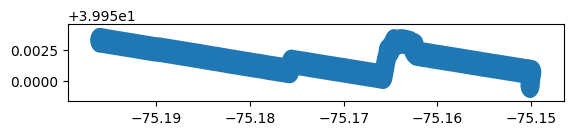

In [10]:
directions.buffer(0.001).plot()

In [11]:
crash_df = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

In [12]:
crash_2024 = crash_df.query('CRASH_YEAR==2024 and COUNTY==67')
crash_2024.shape

(7425, 99)

In [13]:
geom=gpd.points_from_xy(crash_2024['DEC_LONGITUDE'],
                        crash_2024['DEC_LATITUDE']
                  )

crash_2024_gdf = gpd.GeoDataFrame(crash_2024,
                                  geometry=geom, crs='EPSG:4326')

/tmp/ipykernel_3202782/3819416956.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  directions.buffer(0.001).plot(ax=base, color='red')


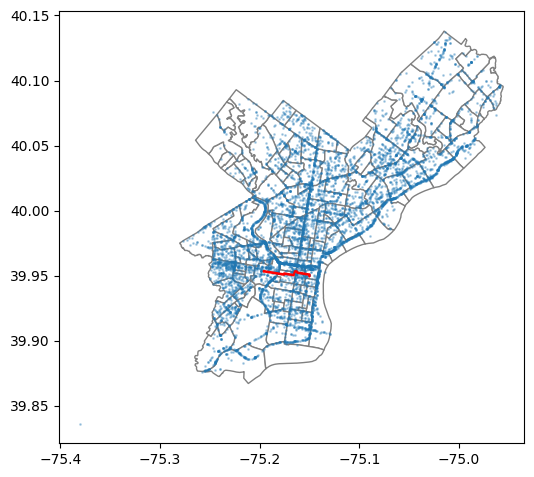

In [14]:
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

base=philly_gdf.plot(color='white', 
                     edgecolor='gray', figsize=(6,6))

crash_2024_gdf.plot(ax=base, markersize=1, alpha=0.3)
directions.buffer(0.001).plot(ax=base, color='red')
plt.show()

In [15]:
#tolerance = 1

#points_on_line = crash_2024_gdf.intersects(directions.buffer(0.001), align=False)

buf_gdf = gpd.GeoDataFrame(geometry=directions.buffer(0.001), crs='EPSG:4326')

on_line = gpd.sjoin(crash_2024_gdf, buf_gdf, predicate='intersects', how='inner')

/tmp/ipykernel_3202782/831988691.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buf_gdf = gpd.GeoDataFrame(geometry=directions.buffer(0.001), crs='EPSG:4326')


<Axes: >

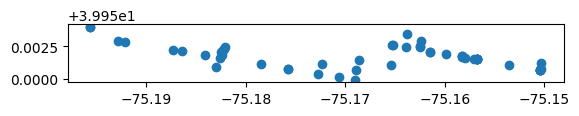

In [16]:
on_line.plot()

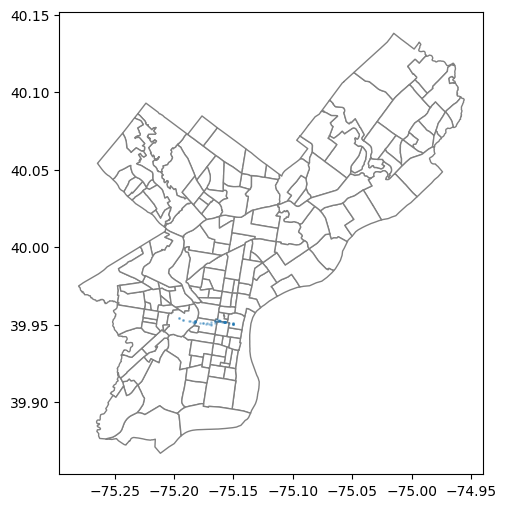

In [17]:
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

base=philly_gdf.plot(color='white', 
                     edgecolor='gray', figsize=(6,6))

on_line.plot(ax=base, markersize=1, alpha=0.3)
#directions.buffer(0.001).plot(ax=base, color='red')
plt.show()

In [18]:
cnt_cols = [c for c in on_line.columns if c.count('_COUNT') and c.count('_')==1]

In [19]:
on_line[cnt_cols].sum()

AUTOMOBILE_COUNT      2
BICYCLE_COUNT         0
BUS_COUNT             1
FATAL_COUNT           0
INJURY_COUNT         53
MOTORCYCLE_COUNT      0
NONMOTR_COUNT         0
PED_COUNT             0
PERSON_COUNT        132
SUV_COUNT             0
VAN_COUNT             0
VEHICLE_COUNT         4
dtype: int64

In [20]:
on_line.query('PERSON_COUNT>2')

,CRN,ARRIVAL_TM,AUTOMOBILE_COUNT,BELTED_DEATH_COUNT,BELTED_SUSP_SERIOUS_INJ_COUNT,BICYCLE_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_SUSP_SERIOUS_INJ_COUNT,BUS_COUNT,CHLDPAS_DEATH_COUNT,...,WZ_CLOSE_DETOUR,WZ_FLAGGER,WZ_LAW_OFFCR_IND,WZ_LN_CLOSURE,WZ_MOVING,WZ_OTHER,WZ_SHLDER_MDN,WZ_WORKERS_INJ_KILLED,geometry,index_right
663980,2024014176,1042.0,0,0,0,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.19282 39.9529),0
665001,2024018660,257.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.16905 39.94994),0
668245,2024031581,1600.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.15801 39.95163),0
669745,2024035825,711.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.18294 39.95089),0
674879,2024055621,408.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.18207 39.95242),0
676230,2024060956,NaN,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.18242 39.95183),0
676269,2024061160,NaN,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.15671 39.95155),0
677048,2024064436,2353.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.15037 39.95071),0
677332,2024065530,2224.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.15704 39.95151),0
680270,2024077589,NaN,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-75.18244 39.95204),0


In [21]:
on_line.value_counts('COLLISION_TYPE')

COLLISION_TYPE
8    24
4    11
1     9
5     7
7     1
Name: count, dtype: int64

In [22]:
ctype = '''
0 – Non-collision
1 – Rear-end
2 – Head-on
3 – Backing
4 – Angle
5 – Sideswipe (same dir.)
6 – Sideswipe (Opposite dir.)
7 – Hit Fixed Object
8 – Hit Non-Motorist
9 – Other/Unknown (Expired)
98 – Other
99 - Unknown
'''

ctype.splitlines()

['',
 '0 – Non-collision',
 '1 – Rear-end',
 '2 – Head-on',
 '3 – Backing',
 '4 – Angle',
 '5 – Sideswipe (same dir.)',
 '6 – Sideswipe (Opposite dir.)',
 '7 – Hit Fixed Object',
 '8 – Hit Non-Motorist',
 '9 – Other/Unknown (Expired)',
 '98 – Other',
 '99 - Unknown']